<a href="https://colab.research.google.com/github/Fantiflex/Modular_Manifold_Muon/blob/main/HW2_pb2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

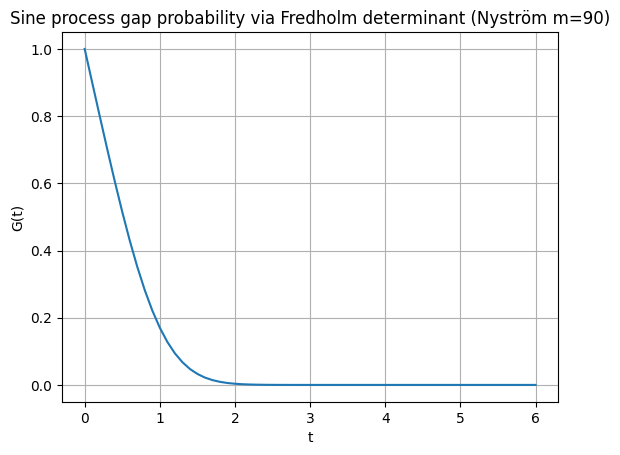

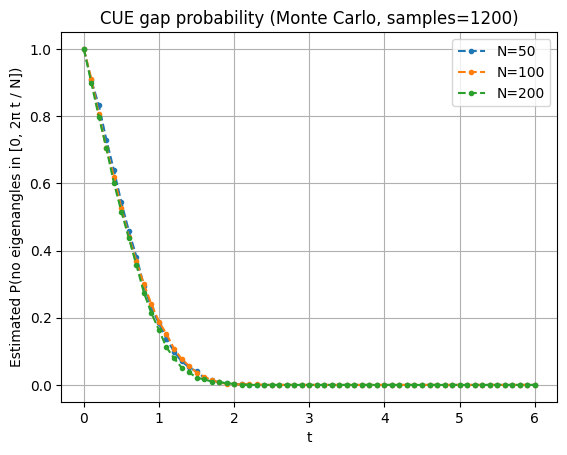

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
#  Sine kernel and Fredholm det
# -----------------------------
def sine_kernel(x, y):
    """K_sin(x,y) = sin(pi(x-y))/(pi(x-y)), continuous at x=y."""
    d = x - y
    out = np.empty_like(d, dtype=float)
    mask = d != 0
    out[mask] = np.sin(np.pi * d[mask]) / (np.pi * d[mask])
    out[~mask] = 1.0
    return out


def fredholm_gap_probability(t, m=80):
    """
    Nyström approximation of G(t) = det(I - K) on L^2([0,t]) for the sine kernel,
    using m-point Gauss–Legendre quadrature.
    """
    if t <= 0:
        return 1.0

    # Gauss–Legendre nodes/weights on [-1,1]
    nodes, weights = np.polynomial.legendre.leggauss(m)

    # Map to [0,t]
    x = 0.5 * t * (nodes + 1.0)
    w = 0.5 * t * weights

    # Nyström matrix A_ij = sqrt(w_i) K(x_i,x_j) sqrt(w_j)
    X = x[:, None]
    Y = x[None, :]
    K = sine_kernel(X, Y)
    A = (np.sqrt(w)[:, None] * K) * np.sqrt(w)[None, :]

    return float(np.linalg.det(np.eye(m) - A))


# -----------------------------
#  Haar unitary sampling (QR)
# -----------------------------
def haar_unitary_via_qr(N, rng):
    """
    Sample Haar unitary U(N) using QR of complex Ginibre.
    """
    Z = (rng.standard_normal((N, N)) + 1j * rng.standard_normal((N, N))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(Z)
    diag = np.diag(R)
    phases = diag / np.abs(diag)
    Q = Q * np.conj(phases)[None, :]
    return Q


def cue_gap_probability_mc(t, N, n_samples=2000, seed=0):
    """
    Monte Carlo estimate of P(no eigenangles in [0, 2π t / N]) for CUE(N).
    """
    rng = np.random.default_rng(seed)
    arc_end = 2.0 * np.pi * t / N
    count_gap = 0

    for _ in range(n_samples):
        U = haar_unitary_via_qr(N, rng)
        eigvals = np.linalg.eigvals(U)
        angles = np.mod(np.angle(eigvals), 2.0 * np.pi)  # map to [0,2π)

        # "No eigenangle in [0, arc_end]"
        if not np.any((angles >= 0.0) & (angles <= arc_end)):
            count_gap += 1

    return count_gap / n_samples


# -----------------------------
#  Main: compute and make 2 plots
# -----------------------------
def main():
    # t grid
    t_vals = np.linspace(0.0, 6.0, 61)

    # ---- Plot 1: Fredholm determinant curve (sine process)
    m_quad = 90  # increase for accuracy (e.g., 120)
    G_fd = np.array([fredholm_gap_probability(t, m=m_quad) for t in t_vals])

    plt.figure()
    plt.plot(t_vals, G_fd)
    plt.xlabel("t")
    plt.ylabel("G(t)")
    plt.title(f"Sine process gap probability via Fredholm determinant (Nyström m={m_quad})")
    plt.grid(True)

    # ---- Plot 2: Monte Carlo for finite-N CUE (several N on same plot)
    Ns = [50, 100, 1000]
    n_samples = 1200  # increase for smoother curves
    plt.figure()

    for N in Ns:
        G_mc = np.array([cue_gap_probability_mc(t, N, n_samples=n_samples, seed=1234 + N) for t in t_vals])
        plt.plot(t_vals, G_mc, marker="o", linestyle="--", markersize=3, label=f"N={N}")

    plt.xlabel("t")
    plt.ylabel("Estimated P(no eigenangles in [0, 2π t / N])")
    plt.title(f"CUE gap probability (Monte Carlo, samples={n_samples})")
    plt.grid(True)
    plt.legend()

    plt.show()


if __name__ == "__main__":
    main()

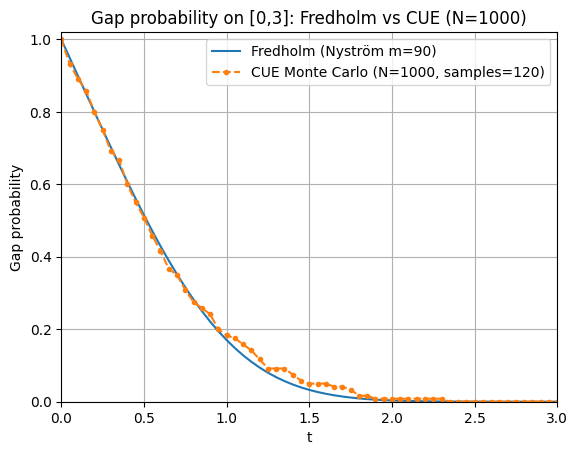

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Fredholm determinant (Nyström)
# -----------------------------
def sine_kernel(x, y):
    d = x - y
    out = np.empty_like(d, dtype=float)
    mask = d != 0
    out[mask] = np.sin(np.pi * d[mask]) / (np.pi * d[mask])
    out[~mask] = 1.0
    return out


def fredholm_gap_probability(t, m=90):
    """G(t) ≈ det(I - K) on [0,t] via m-point Gauss–Legendre Nyström."""
    if t <= 0:
        return 1.0
    nodes, weights = np.polynomial.legendre.leggauss(m)  # on [-1,1]
    x = 0.5 * t * (nodes + 1.0)                          # map to [0,t]
    w = 0.5 * t * weights
    K = sine_kernel(x[:, None], x[None, :])
    A = (np.sqrt(w)[:, None] * K) * np.sqrt(w)[None, :]
    return float(np.linalg.det(np.eye(m) - A))


# -----------------------------
# CUE Monte Carlo (reuse angles)
# -----------------------------
def haar_unitary_via_qr(N, rng):
    Z = (rng.standard_normal((N, N)) + 1j * rng.standard_normal((N, N))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(Z)
    d = np.diag(R)
    phases = d / np.abs(d)
    Q = Q * np.conj(phases)[None, :]
    return Q


def cue_angles_samples(N, n_samples, seed=0):
    """Generate eigenangles once; reuse for all t."""
    rng = np.random.default_rng(seed)
    angles = np.empty((n_samples, N), dtype=float)
    for s in range(n_samples):
        U = haar_unitary_via_qr(N, rng)
        eigvals = np.linalg.eigvals(U)
        angles[s] = np.mod(np.angle(eigvals), 2 * np.pi)  # [0,2π)
    return angles


def cue_gap_curve_from_angles(t_vals, angles):
    """Estimate P(no eigenangles in [0, 2π t / N]) for each t."""
    n_samples, N = angles.shape
    G = np.zeros_like(t_vals, dtype=float)
    for k, t in enumerate(t_vals):
        arc_end = 2 * np.pi * t / N
        has_in_arc = np.any((angles >= 0.0) & (angles <= arc_end), axis=1)
        G[k] = 1.0 - np.mean(has_in_arc)
    return G


# -----------------------------
# Main: overlay N=1000 vs Fredholm on [0,3]
# -----------------------------
def main():
    # Zoom interval
    t_vals = np.linspace(0.0, 3.0, 61)

    # Fredholm curve
    m_quad = 90
    G_fd = np.array([fredholm_gap_probability(t, m=m_quad) for t in t_vals])

    # CUE Monte Carlo for N=1000
    N = 1000
    n_samples = 120  # increase (e.g. 300) if you want smoother, but slower
    angles = cue_angles_samples(N, n_samples=n_samples, seed=12345)
    G_mc = cue_gap_curve_from_angles(t_vals, angles)

    # Plot overlay
    plt.figure()
    plt.plot(t_vals, G_fd, label=f"Fredholm (Nyström m={m_quad})")
    plt.plot(t_vals, G_mc, marker="o", linestyle="--", markersize=3,
             label=f"CUE Monte Carlo (N={N}, samples={n_samples})")
    plt.xlim(0.0, 3.0)
    plt.ylim(0.0, 1.02)
    plt.xlabel("t")
    plt.ylabel("Gap probability")
    plt.title("Gap probability on [0,3]: Fredholm vs CUE (N=1000)")
    plt.grid(True)
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()